In [92]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [93]:
df = pd.read_csv("insurance.csv")

In [94]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [95]:
df.shape

(1338, 7)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [97]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [98]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [99]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [100]:
numeric_column = df.select_dtypes(include=['number']) # numeric values

In [101]:
numeric_column

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


In [102]:
categorical_column=df.select_dtypes(include=['object'])

In [103]:
categorical_column # string values

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


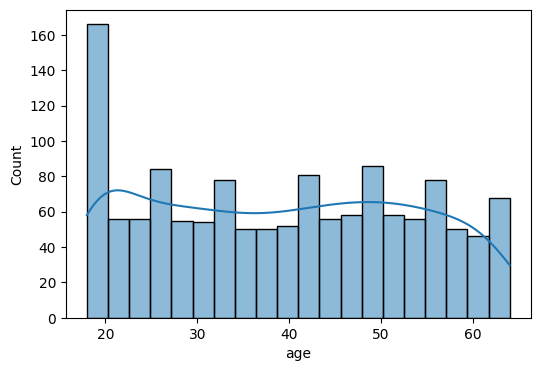

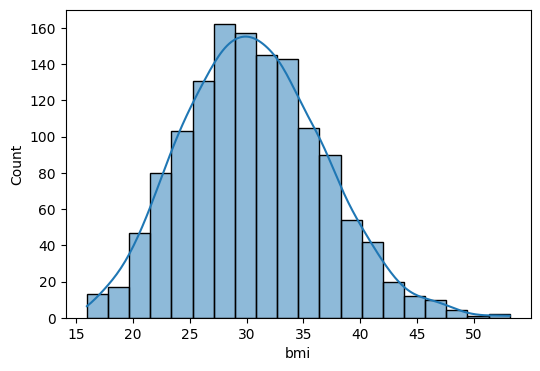

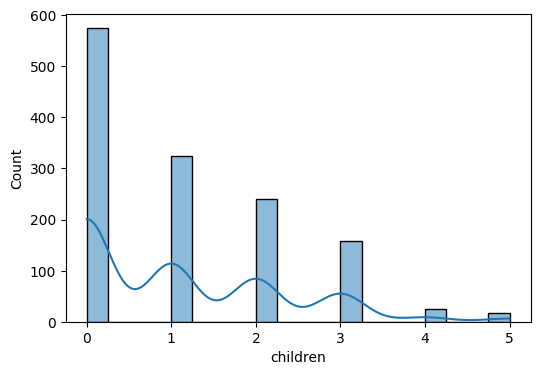

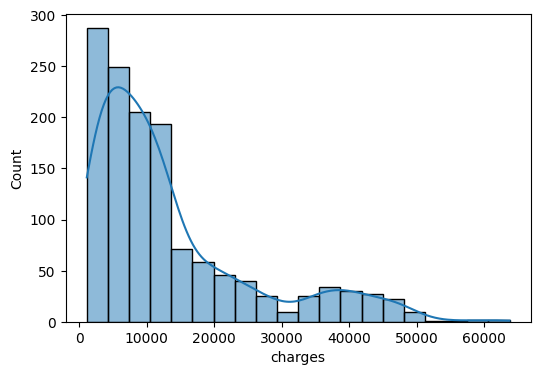

In [104]:
# plotting the histogram of all the numeric_column  using loop 
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col] , kde=True, bins=20)

<Axes: xlabel='children', ylabel='count'>

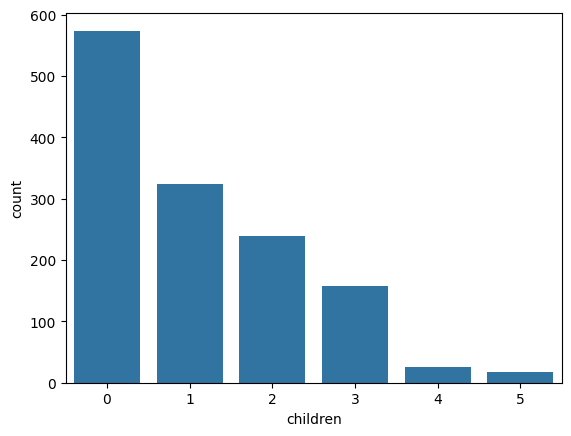

In [105]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

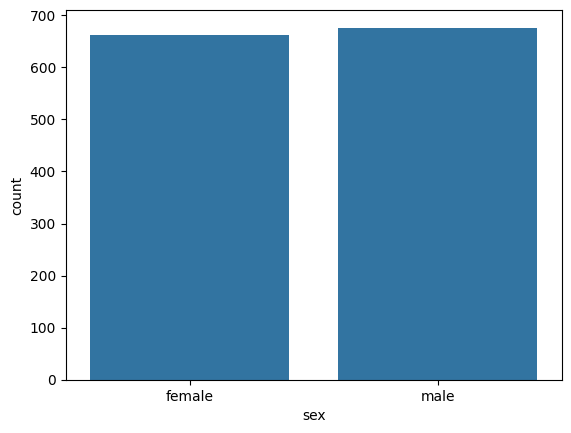

In [106]:
sns.countplot(x=df['sex'])

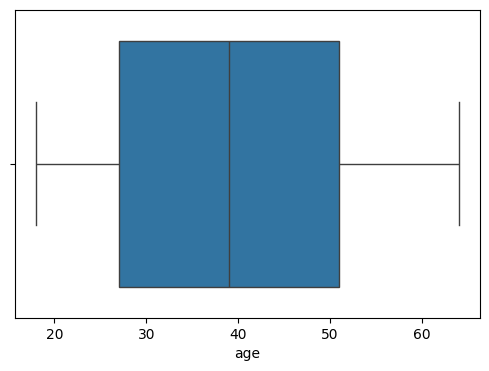

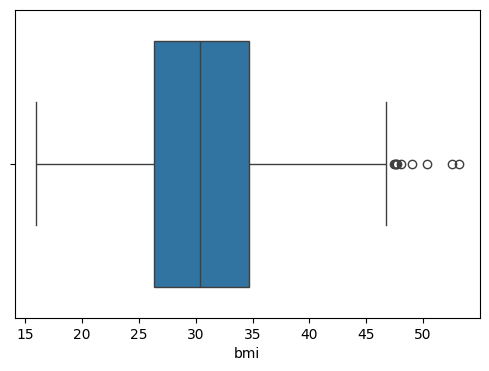

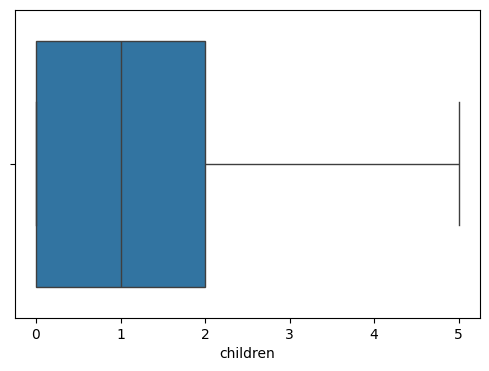

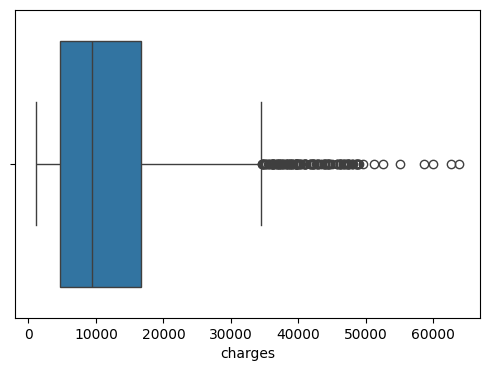

In [107]:
# plotting the boxplot of all the numeric_column  using loop 
for col in numeric_column:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

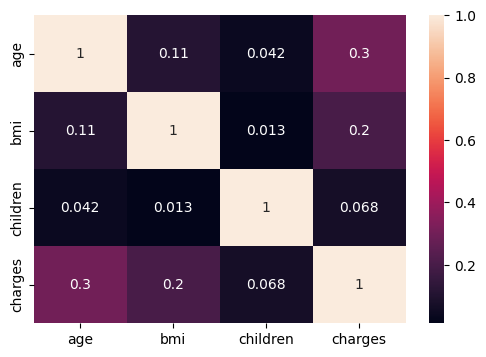

In [108]:
# plotting the heatmap of the correlation of the numeroic_column 
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only= True),annot=True)

# data preprocessing and cleaning

In [109]:
df.shape 
# just for the see the shape original shape if there will duplicate then its shape reduce 

(1338, 7)

In [110]:
df_cleaned = df.drop_duplicates() # it will remove the duplicates
df_cleaned.shape 

(1337, 7)

In [111]:
df_cleaned['sex'].value_counts() # it gives you the total number of each

sex
male      675
female    662
Name: count, dtype: int64

# conversion of categorical into the numeric

In [112]:
categorical_column

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [113]:
df_cleaned['sex'] = df_cleaned['sex'].map({"male":0, "female":1})

In [114]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({"no":0, "yes":1})

In [115]:
df_cleaned.head() # see the changes in the encoding like categorical to nnumeric

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [123]:
df_cleaned = pd.get_dummies(df_cleaned) # we are saving and doing the one-hot encoding 

In [126]:
cols = ['region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']

df_cleaned[cols] = df_cleaned[cols].astype(int) # this convert the true as 1 and false as 0

In [128]:
df_cleaned.head() # you can see all the categorical changes to the numeric 

# note we use one hot encoding for the region

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,0,0,0,1
1,18,0,33.770,1,0,1725.55230,0,0,1,0
2,28,0,33.000,3,0,4449.46200,0,0,1,0
3,33,0,22.705,0,0,21984.47061,0,1,0,0
4,32,0,28.880,0,0,3866.85520,0,1,0,0
